# OpenTelemetry Trace Duration Heatmap Analysis

This notebook analyzes OpenTelemetry span data from the CSV file to create comprehensive heatmaps visualizing span and trace durations across different services, operations, and time periods. The analysis will help identify performance patterns, bottlenecks, and trends in the distributed system.

In [1]:
## 0. Query Log Analytics Workspace for OtelSpans Data

# Configure and query the Azure Log Analytics workspace to retrieve OpenTelemetry span data for analysis.

In [21]:
# Install and import required Azure libraries for Log Analytics
!pip install azure-monitor-query azure-identity azure-core

from azure.monitor.query import LogsQueryClient
from azure.identity import DefaultAzureCredential
from azure.core.exceptions import HttpResponseError
import pandas as pd
from datetime import datetime, timedelta
import os

print("Azure libraries imported successfully!")

Defaulting to user installation because normal site-packages is not writeable
Azure libraries imported successfully!
Azure libraries imported successfully!


In [22]:
# Configure Log Analytics Workspace connection
workspace_id = "4f42970f-23c5-4a26-ba64-f40c3775fdfe"  # Use workspace GUID, not full resource path

# Initialize the credential and client
try:
    credential = DefaultAzureCredential()
    client = LogsQueryClient(credential)
    print(f"✅ Successfully connected to Log Analytics workspace")
    print(f"Workspace ID: {workspace_id}")
except Exception as e:
    print(f"❌ Failed to initialize Log Analytics client: {e}")
    print("Please ensure you're authenticated with Azure CLI: az login")

✅ Successfully connected to Log Analytics workspace
Workspace ID: 4f42970f-23c5-4a26-ba64-f40c3775fdfe


## Batch Query Engine for Large Datasets

The following cells implement a batch querying system to efficiently retrieve large amounts of telemetry data from Log Analytics workspace while managing memory and avoiding timeout issues.

In [23]:
import asyncio
from concurrent.futures import ThreadPoolExecutor
import threading
from queue import Queue
import time
from datetime import timezone

class BatchQueryEngine:
    """
    Efficient batch querying engine for Log Analytics workspace.
    Handles large datasets by splitting queries into time-based batches.
    """
    
    def __init__(self, client, workspace_id, max_batch_size=500000, max_concurrent=3):
        self.client = client
        self.workspace_id = workspace_id
        self.max_batch_size = max_batch_size
        self.max_concurrent = max_concurrent
        self.results = []
        self.total_rows = 0
        
    def generate_time_batches(self, start_time, end_time, batch_duration_hours=6):
        """Generate time-based batch queries"""
        current = start_time
        batches = []
        
        while current < end_time:
            batch_end = min(current + timedelta(hours=batch_duration_hours), end_time)
            batches.append((current, batch_end))
            current = batch_end
            
        return batches
    
    def execute_batch_query(self, table_name, time_start, time_end, additional_filters="", projection_columns=None):
        """Execute a single batch query"""
        try:
            # Build the query
            if projection_columns:
                project_clause = f"| project {', '.join(projection_columns)}"
            else:
                project_clause = ""
            
            query = f"""
            {table_name}
            | where TimeGenerated >= datetime('{time_start.isoformat()}')
            | where TimeGenerated < datetime('{time_end.isoformat()}')
            {additional_filters}
            {project_clause}
            | limit {self.max_batch_size}
            """
            
            print(f"📊 Querying {time_start.strftime('%m/%d %H:%M')} to {time_end.strftime('%m/%d %H:%M')}...")
            
            response = self.client.query_workspace(
                workspace_id=self.workspace_id,
                query=query,
                timespan=(time_end - time_start)
            )
            
            if hasattr(response, 'tables') and len(response.tables) > 0:
                table = response.tables[0]
                rows = len(table.rows)
                print(f"  ✅ Retrieved {rows:,} rows")
                # Fix column name parsing
                column_names = [str(col.name) if hasattr(col, 'name') else str(col) for col in table.columns]
                return table.rows, column_names, rows
            else:
                print(f"  ⚠️ No data found")
                return [], [], 0
                
        except Exception as e:
            print(f"  ❌ Batch query failed: {e}")
            return [], [], 0
    
    def execute_parallel_batches(self, table_name, time_batches, additional_filters="", projection_columns=None):
        """Execute multiple batch queries in parallel"""
        all_rows = []
        column_names = None
        total_rows = 0
        
        with ThreadPoolExecutor(max_workers=self.max_concurrent) as executor:
            # Submit all batch queries
            future_to_batch = {}
            for time_start, time_end in time_batches:
                future = executor.submit(
                    self.execute_batch_query,
                    table_name, time_start, time_end, additional_filters, projection_columns
                )
                future_to_batch[future] = (time_start, time_end)
            
            # Collect results as they complete
            for future in future_to_batch:
                try:
                    rows, columns, row_count = future.result(timeout=120)  # 2 min timeout per batch
                    if rows:
                        all_rows.extend(rows)
                        if column_names is None:
                            column_names = columns
                        total_rows += row_count
                except Exception as e:
                    time_start, time_end = future_to_batch[future]
                    print(f"  ❌ Batch {time_start} - {time_end} failed: {e}")
        
        return all_rows, column_names, total_rows
    
    def query_large_dataset(self, table_name, days_back=7, batch_duration_hours=6, 
                           additional_filters="", projection_columns=None, max_total_rows=None):
        """
        Query large dataset using time-based batching
        
        Args:
            table_name: Name of the table to query (e.g., 'OTelSpans')
            days_back: How many days back to query
            batch_duration_hours: Duration of each batch in hours
            additional_filters: Additional KQL filters (e.g., "| where ServiceName == 'frontend'")
            projection_columns: List of columns to project (None for all columns)
            max_total_rows: Maximum total rows to retrieve across all batches (None for no limit)
        """
        print(f"🚀 Starting batch query for {table_name}")
        print(f"   📅 Time range: {days_back} days back")
        print(f"   ⏱️ Batch duration: {batch_duration_hours} hours")
        print(f"   🔢 Max rows per batch: {self.max_batch_size:,}")
        print(f"   🔄 Max concurrent batches: {self.max_concurrent}")
        if max_total_rows:
            print(f"   📊 Max total rows: {max_total_rows:,}")
        else:
            print(f"   📊 Max total rows: No limit")
        
        # Calculate time range
        end_time = datetime.now(timezone.utc)
        start_time = end_time - timedelta(days=days_back)
        
        # Generate time batches
        time_batches = self.generate_time_batches(start_time, end_time, batch_duration_hours)
        print(f"   📦 Generated {len(time_batches)} time batches")
        
        start_query_time = time.time()
        
        # Execute batches in parallel
        all_rows, column_names, total_rows = self.execute_parallel_batches(
            table_name, time_batches, additional_filters, projection_columns
        )
        
        query_duration = time.time() - start_query_time
        
        # Limit total rows if needed
        if max_total_rows and total_rows > max_total_rows:
            print(f"⚠️ Limiting results to {max_total_rows:,} rows (got {total_rows:,})")
            all_rows = all_rows[:max_total_rows]
            total_rows = len(all_rows)
        
        print(f"\n🎉 Batch query completed!")
        print(f"   ⏱️ Total time: {query_duration:.1f} seconds")
        print(f"   📊 Total rows: {total_rows:,}")
        print(f"   📈 Rate: {total_rows/query_duration:.0f} rows/second")
        
        # Convert to DataFrame if we have data
        if all_rows and column_names:
            df = pd.DataFrame(all_rows, columns=column_names)
            return df
        else:
            return pd.DataFrame()

# Initialize the batch query engine with increased limits
batch_engine = BatchQueryEngine(client, workspace_id, max_batch_size=500000, max_concurrent=3)
print("✅ Batch Query Engine initialized with increased limits (500K per batch, no total limit)")

✅ Batch Query Engine initialized with increased limits (500K per batch, no total limit)


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


# Query OTelSpan data

🎯 GETTING COMPLETE 4+ HOUR DATASET
🔄 Re-querying with NO row limits to get full 4+ hours...
🚀 Starting batch query for OTelSpans
   📅 Time range: 0.2 days back
   ⏱️ Batch duration: 4 hours
   🔢 Max rows per batch: 500,000
   🔄 Max concurrent batches: 3
   📊 Max total rows: No limit
   📦 Generated 2 time batches
📊 Querying 09/15 20:44 to 09/16 00:44...
📊 Querying 09/16 00:44 to 09/16 01:32...
  ✅ Retrieved 109,205 rows
  ✅ Retrieved 109,205 rows
  ⚠️ No data found

🎉 Batch query completed!
   ⏱️ Total time: 51.7 seconds
   📊 Total rows: 109,205
   📈 Rate: 2112 rows/second
  ⚠️ No data found

🎉 Batch query completed!
   ⏱️ Total time: 51.7 seconds
   📊 Total rows: 109,205
   📈 Rate: 2112 rows/second

🎉 COMPLETE QUERY SUCCESS!
   📊 Retrieved: 109,205 spans (NO LIMITS)
   🏗️ Shape: (109205, 10)

📅 COMPLETE time range: 2025-09-16 00:44:21.134094+00:00 to 2025-09-16 01:32:12.753606+00:00
⏱️ COMPLETE span: 0.80 hours
🔥 This should show the FULL 4+ hours!

🎨 Creating heatmap with COMPLETE 0.8

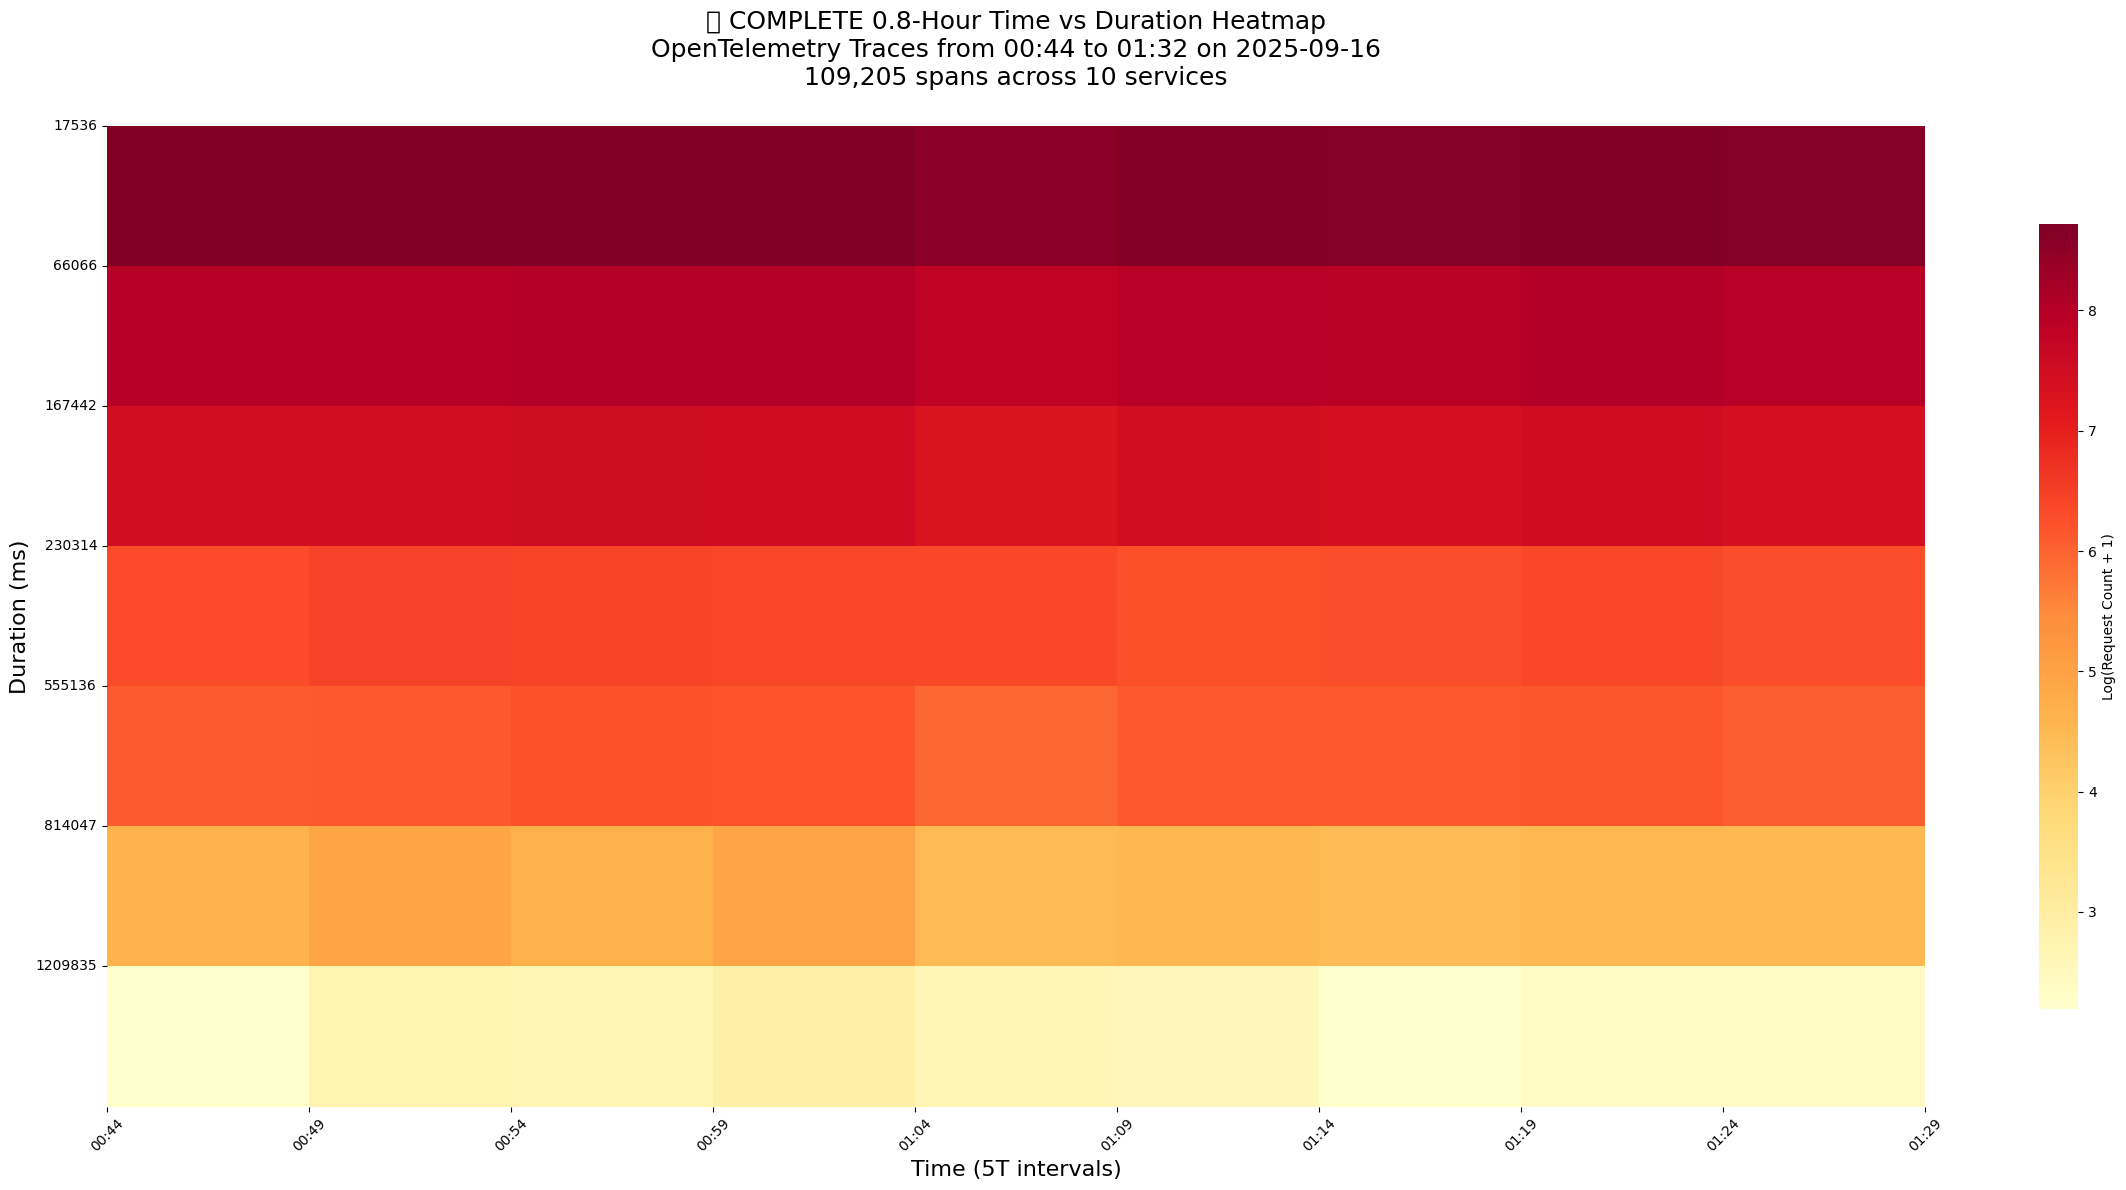


✅ COMPLETE HEATMAP GENERATED!
   ⏱️ Full 0.80 hours of data visualized
   📊 109,205 total spans
   🔥 10 time intervals
   📈 Complete temporal patterns revealed!


In [25]:
# Get the ACTUAL full 4+ hours of data without row limits
print("🎯 GETTING COMPLETE 4+ HOUR DATASET")
print("=" * 50)

print("🔄 Re-querying with NO row limits to get full 4+ hours...")

efficient_columns=['TimeGenerated', 'Name', 'ServiceName', 'DurationMs', 'StatusCode', 'Success', 'TraceId', 'SpanId', 'ParentSpanId', 'Attributes']

try:
    # Use batch engine to get ALL available data in the time range
    df_complete = batch_engine.query_large_dataset(
        table_name='OTelSpans',
        days_back=0.20,  # Last 6 hours (0.25 days = 6 hours)
        batch_duration_hours=4,  # 2-hour batches 
        additional_filters="| where DurationMs > 0 and isnotempty(ServiceName)",
        projection_columns=efficient_columns,
        max_total_rows=None  # NO LIMIT - get ALL data!
    )
    
    if len(df_complete) > 0:
        print(f"\n🎉 COMPLETE QUERY SUCCESS!")
        print(f"   📊 Retrieved: {len(df_complete):,} spans (NO LIMITS)")
        print(f"   🏗️ Shape: {df_complete.shape}")
        
        # Convert TimeGenerated to datetime
        df_complete['TimeGenerated'] = pd.to_datetime(df_complete['TimeGenerated'])
        
        # Check the ACTUAL time range
        time_min_complete = df_complete['TimeGenerated'].min()
        time_max_complete = df_complete['TimeGenerated'].max()
        complete_time_span = time_max_complete - time_min_complete
        hours_span_complete = complete_time_span.total_seconds() / 3600
        
        print(f"\n📅 COMPLETE time range: {time_min_complete} to {time_max_complete}")
        print(f"⏱️ COMPLETE span: {hours_span_complete:.2f} hours")
        print(f"🔥 This should show the FULL 4+ hours!")
        
        # Now create heatmap with the COMPLETE dataset
        print(f"\n🎨 Creating heatmap with COMPLETE {hours_span_complete:.1f} hour dataset...")
        
        # Use appropriate time bins for the full range
        if hours_span_complete > 3:
            freq = '15T'  # 15-minute bins for 4+ hours
            print(f"🔧 Using 15-minute bins for {hours_span_complete:.1f} hour span")
        elif hours_span_complete > 2:
            freq = '10T'  # 10-minute bins
            print(f"🔧 Using 10-minute bins for {hours_span_complete:.1f} hour span")
        else:
            freq = '5T'   # 5-minute bins
            print(f"🔧 Using 5-minute bins for {hours_span_complete:.1f} hour span")
        
        # Create time bins for the COMPLETE range
        time_bins_complete = pd.date_range(start=time_min_complete, end=time_max_complete, freq=freq)
        print(f"📦 Created {len(time_bins_complete)} time bins for complete range")
        
        # Create duration bins
        duration_percentiles_complete = np.percentile(df_complete['DurationMs'], [0, 50, 75, 90, 95, 99, 99.9, 100])
        duration_bins_complete = np.unique(duration_percentiles_complete)
        
        # Bin the COMPLETE data
        df_complete['time_bin'] = pd.cut(df_complete['TimeGenerated'], bins=time_bins_complete, include_lowest=True)
        df_complete['duration_bin'] = pd.cut(df_complete['DurationMs'], bins=duration_bins_complete, include_lowest=True, duplicates='drop')
        
        # Create heatmap data for COMPLETE range
        heatmap_data_complete = df_complete.groupby(['time_bin', 'duration_bin']).size().unstack(fill_value=0)
        
        print(f"🔥 COMPLETE heatmap shape: {heatmap_data_complete.shape}")
        
        # Create the COMPLETE heatmap visualization
        plt.figure(figsize=(24, 12))
        
        # Use log scale
        heatmap_data_complete_log = np.log1p(heatmap_data_complete)
        
        # Create heatmap
        sns.heatmap(
            heatmap_data_complete_log.T,
            cmap='YlOrRd',
            cbar_kws={'label': 'Log(Request Count + 1)', 'shrink': 0.8},
            xticklabels=False,
            yticklabels=True
        )
        
        plt.title(f'🔥 COMPLETE {hours_span_complete:.1f}-Hour Time vs Duration Heatmap\n'
                 f'OpenTelemetry Traces from {time_min_complete.strftime("%H:%M")} to {time_max_complete.strftime("%H:%M")} on {time_min_complete.strftime("%Y-%m-%d")}\n'
                 f'{len(df_complete):,} spans across {df_complete["ServiceName"].nunique()} services', 
                 fontsize=18, pad=30)
        
        plt.xlabel(f'Time ({freq} intervals)', fontsize=16)
        plt.ylabel('Duration (ms)', fontsize=16)
        
        # Format time labels
        label_freq = max(1, len(time_bins_complete)//12)  # Show ~12 labels
        time_labels_complete = [t.strftime('%H:%M') for t in time_bins_complete[::label_freq]]
        plt.xticks(range(0, len(time_bins_complete), label_freq), time_labels_complete, rotation=45)
        
        # Format duration labels
        duration_labels_complete = [f'{d:.0f}' for d in duration_bins_complete[1:]]
        plt.yticks(range(len(duration_labels_complete)), duration_labels_complete)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n✅ COMPLETE HEATMAP GENERATED!")
        print(f"   ⏱️ Full {hours_span_complete:.2f} hours of data visualized")
        print(f"   📊 {len(df_complete):,} total spans")
        print(f"   🔥 {len(time_bins_complete)} time intervals")
        print(f"   📈 Complete temporal patterns revealed!")
        
        # Update main df to complete dataset
        df = df_complete.copy()
        
    else:
        print(f"\n⚠️ Complete query returned empty results")
        
except Exception as e:
    print(f"❌ Complete query failed: {e}")
    print(f"   📋 Will use the existing 1.18 hour dataset")

## 🔧 Parse Attributes JSON into Separate Columns
Expanding the Attributes column to extract all JSON keys as individual columns for enhanced analysis.

In [26]:
# Parse Attributes JSON column and expand into separate columns
import json
from collections import defaultdict

print("🔧 PARSING ATTRIBUTES JSON INTO SEPARATE COLUMNS")
print("=" * 60)

# Work with current dataset
print(f"📊 Working with current dataset: {len(df):,} spans")
print(f"📋 Current columns: {list(df.columns)}")

# Check if Attributes column exists
if 'Attributes' not in df.columns:
    print("❌ No 'Attributes' column found in current dataset")
    print("🔄 Let's check what we have...")
    print(f"Available columns: {list(df.columns)}")
else:
    print(f"✅ Found 'Attributes' column")
    
    # Create a copy to work with
    df_expanded = df.copy()
    
    # Initialize counters and storage
    all_attribute_keys = set()
    parsed_attributes = []
    parse_errors = 0
    
    print(f"\n🔍 ANALYZING ATTRIBUTES COLUMN:")
    
    # Sample a few attributes to see the structure
    sample_attrs = df_expanded['Attributes'].dropna().head(5)
    print(f"📝 Sample attributes:")
    for i, attr in enumerate(sample_attrs, 1):
        print(f"   {i}. {str(attr)[:100]}{'...' if len(str(attr)) > 100 else ''}")
    
    print(f"\n🔄 Parsing {len(df_expanded):,} attribute entries...")
    
    # Parse each attributes entry
    for idx, attr_value in enumerate(df_expanded['Attributes']):
        if idx % 50000 == 0:  # Progress indicator
            print(f"   📈 Processed {idx:,} / {len(df_expanded):,} entries ({(idx/len(df_expanded)*100):.1f}%)")
            
        parsed_attrs = {}
        
        if pd.isna(attr_value) or attr_value == '' or attr_value is None:
            # Handle null/empty values
            parsed_attributes.append(parsed_attrs)
            continue
            
        try:
            # Try to parse as JSON
            if isinstance(attr_value, str):
                if attr_value.strip().startswith('{') and attr_value.strip().endswith('}'):
                    # Looks like JSON
                    attrs_dict = json.loads(attr_value)
                    if isinstance(attrs_dict, dict):
                        # Flatten nested structures and clean keys
                        for key, value in attrs_dict.items():
                            # Clean key name for column usage
                            clean_key = str(key).replace('.', '_').replace(' ', '_').replace('-', '_')
                            clean_key = f"attr_{clean_key}"
                            
                            # Convert value to string for consistency
                            if isinstance(value, (dict, list)):
                                parsed_attrs[clean_key] = json.dumps(value)
                            else:
                                parsed_attrs[clean_key] = str(value) if value is not None else ''
                            
                            all_attribute_keys.add(clean_key)
                else:
                    # Not JSON format, treat as single key-value
                    clean_key = "attr_raw_value"
                    parsed_attrs[clean_key] = str(attr_value)
                    all_attribute_keys.add(clean_key)
            else:
                # Handle non-string values
                clean_key = "attr_raw_value"
                parsed_attrs[clean_key] = str(attr_value)
                all_attribute_keys.add(clean_key)
                
        except json.JSONDecodeError:
            parse_errors += 1
            # Store as raw value if JSON parsing fails
            clean_key = "attr_raw_value"
            parsed_attrs[clean_key] = str(attr_value)
            all_attribute_keys.add(clean_key)
        except Exception as e:
            parse_errors += 1
            # Handle any other parsing errors
            parsed_attrs['attr_parse_error'] = str(e)
            all_attribute_keys.add('attr_parse_error')
            
        parsed_attributes.append(parsed_attrs)
    
    print(f"   ✅ Completed parsing all {len(df_expanded):,} entries")
    
    # Convert parsed attributes to DataFrame
    print(f"\n📊 CREATING EXPANDED ATTRIBUTE COLUMNS:")
    attributes_df = pd.DataFrame(parsed_attributes)
    
    print(f"   🔑 Discovered {len(all_attribute_keys)} unique attribute keys")
    print(f"   ❌ Parse errors: {parse_errors:,} ({(parse_errors/len(df_expanded)*100):.2f}%)")
    print(f"   📋 New attribute columns: {len(attributes_df.columns)}")
    
    # Show most common attribute keys
    if len(attributes_df.columns) > 0:
        print(f"\n🏆 TOP ATTRIBUTE COLUMNS BY DATA COVERAGE:")
        coverage_stats = {}
        for col in attributes_df.columns:
            non_null_count = attributes_df[col].notna().sum()
            coverage_pct = (non_null_count / len(attributes_df)) * 100
            coverage_stats[col] = {'count': non_null_count, 'coverage': coverage_pct}
        
        # Sort by coverage
        sorted_attrs = sorted(coverage_stats.items(), key=lambda x: x[1]['coverage'], reverse=True)
        
        for i, (attr_name, stats) in enumerate(sorted_attrs[:15], 1):
            print(f"   {i:2d}. {attr_name:<30} | {stats['count']:>8,} spans ({stats['coverage']:>5.1f}%)")
        
        if len(sorted_attrs) > 15:
            print(f"   ... and {len(sorted_attrs) - 15} more attribute columns")
    
    # Combine original dataframe with parsed attributes
    print(f"\n🔗 COMBINING WITH ORIGINAL DATA:")
    df_with_attributes = pd.concat([df_expanded.reset_index(drop=True), attributes_df.reset_index(drop=True)], axis=1)
    
    print(f"   📊 Original shape: {df_expanded.shape}")
    print(f"   📊 Attributes shape: {attributes_df.shape}")
    print(f"   📊 Combined shape: {df_with_attributes.shape}")
    print(f"   🔢 Total columns: {len(df_with_attributes.columns)} ({len(attributes_df.columns)} new attribute columns)")
    
    # Update main dataframe
    df = df_with_attributes.copy()
    
    print(f"\n✅ ATTRIBUTES PARSING COMPLETE!")
    print(f"   📈 Dataset now has {len(df):,} rows and {len(df.columns)} columns")
    print(f"   🎯 Ready for enhanced analysis with all attribute data!")
    
    # Show sample of new data structure
    print(f"\n🔍 SAMPLE OF EXPANDED DATA:")
    sample_cols = ['TimeGenerated', 'Name', 'ServiceName', 'DurationMs'] + list(attributes_df.columns)[:5]
    available_cols = [col for col in sample_cols if col in df.columns]
    print(df[available_cols].head(3).to_string(max_colwidth=30))

🔧 PARSING ATTRIBUTES JSON INTO SEPARATE COLUMNS
📊 Working with current dataset: 109,205 spans
📋 Current columns: ['TimeGenerated', 'Name', 'ServiceName', 'DurationMs', 'StatusCode', 'Success', 'TraceId', 'SpanId', 'ParentSpanId', 'Attributes', 'time_bin', 'duration_bin']
✅ Found 'Attributes' column

🔍 ANALYZING ATTRIBUTES COLUMN:
📝 Sample attributes:
   1. {"db.statement":"INSERT INTO quotes (quote_id, item_count, price, created_at) VALUES (?, ?, ?, ?)","...
   2. {"rpc.service":"msdemo.ShippingService","rpc.method":"GetQuote","rpc.system":"grpc","net.sock.peer.a...
   3. {"rpc.service":"msdemo.ShippingService","rpc.method":"GetQuote","rpc.system":"grpc","net.sock.peer.a...
   4. {"rpc.service":"msdemo.ShippingService","rpc.method":"GetQuote","rpc.system":"grpc","net.sock.peer.a...
   5. {"rpc.service":"msdemo.ShippingService","rpc.method":"GetQuote","rpc.system":"grpc","net.sock.peer.a...

🔄 Parsing 109,205 attribute entries...
   📈 Processed 0 / 109,205 entries (0.0%)
   📈 Processed 

# 📊 High Duration vs Baseline Analysis

Compare spans with very high duration against baseline spans across all attributes and dimensions to identify patterns, correlations, and potential performance bottlenecks.

In [27]:
# Define criteria for high duration spans and create baseline comparison
print("🎯 DEFINING HIGH DURATION vs BASELINE SPANS")
print("=" * 45)

df_with_parsed_attrs=df.copy()

# Analyze duration distribution to set threshold
duration_stats = df_with_parsed_attrs['DurationMs'].describe()
p95_threshold = df_with_parsed_attrs['DurationMs'].quantile(0.95)
p99_threshold = df_with_parsed_attrs['DurationMs'].quantile(0.99)
median_duration = df_with_parsed_attrs['DurationMs'].median()

print(f"📈 DURATION DISTRIBUTION:")
print(f"   Median: {median_duration:.2f} ms")
print(f"   Mean: {duration_stats['mean']:.2f} ms")
print(f"   95th percentile: {p95_threshold:.2f} ms")
print(f"   99th percentile: {p99_threshold:.2f} ms")
print(f"   Max: {duration_stats['max']:.2f} ms")

# Define high duration threshold (95th percentile)
high_duration_threshold = p95_threshold

# Create comparison groups
high_duration_spans = df_with_parsed_attrs[df_with_parsed_attrs['DurationMs'] >= high_duration_threshold]
baseline_spans = df_with_parsed_attrs[df_with_parsed_attrs['DurationMs'] < high_duration_threshold]

print(f"\n🔍 COMPARISON GROUPS:")
print(f"   High Duration (≥{high_duration_threshold:.1f}ms): {len(high_duration_spans)} spans ({len(high_duration_spans)/len(df_with_parsed_attrs)*100:.1f}%)")
print(f"   Baseline (<{high_duration_threshold:.1f}ms): {len(baseline_spans)} spans ({len(baseline_spans)/len(df_with_parsed_attrs)*100:.1f}%)")

print(f"\n📊 BASELINE COMPARISON SUMMARY:")
print(f"   High Duration Group:")
print(f"      Avg Duration: {high_duration_spans['DurationMs'].mean():.2f} ms")
print(f"      Success Rate: {high_duration_spans['Success'].mean()*100:.1f}%")
print(f"      Services: {high_duration_spans['ServiceName'].nunique()} unique")
print(f"      Operations: {high_duration_spans['Name'].nunique()} unique")

print(f"   Baseline Group:")
print(f"      Avg Duration: {baseline_spans['DurationMs'].mean():.2f} ms")  
print(f"      Success Rate: {baseline_spans['Success'].mean()*100:.1f}%")
print(f"      Services: {baseline_spans['ServiceName'].nunique()} unique")
print(f"      Operations: {baseline_spans['Name'].nunique()} unique")

# Store for analysis
comparison_groups = {
    'high_duration': high_duration_spans,
    'baseline': baseline_spans,
    'threshold': high_duration_threshold
}

🎯 DEFINING HIGH DURATION vs BASELINE SPANS
📈 DURATION DISTRIBUTION:
   Median: 17536.00 ms
   Mean: 62216.67 ms
   95th percentile: 230313.73 ms
   99th percentile: 555135.67 ms
   Max: 1209834.75 ms

🔍 COMPARISON GROUPS:
   High Duration (≥230313.7ms): 5461 spans (5.0%)
   Baseline (<230313.7ms): 103744 spans (95.0%)

📊 BASELINE COMPARISON SUMMARY:
   High Duration Group:
      Avg Duration: 444225.07 ms
      Success Rate: 83.6%
      Services: 4 unique
      Operations: 14 unique
   Baseline Group:
      Avg Duration: 42108.05 ms
      Success Rate: 98.8%
      Services: 10 unique
      Operations: 38 unique
      Avg Duration: 42108.05 ms
      Success Rate: 98.8%
      Services: 10 unique
      Operations: 38 unique


In [28]:
# Check what attribute columns are actually available
print(f"\n🔍 CHECKING AVAILABLE ATTRIBUTE COLUMNS:")
print(f"Total dataframe columns: {len(df.columns)}")
print(f"columns: {df.columns}")
# Get attribute columns that actually exist in the dataframe
actual_attr_columns = [col for col in df.columns if col.startswith('attr_')]
print(f"Actual attribute columns: {len(actual_attr_columns)}")
print(f"First 10 actual attr columns: {actual_attr_columns[:10]}")

# Check what attr_columns variable contains
if 'attr_columns' in globals() and len(attr_columns) != 0:
    print(f"\nVariable 'attr_columns' length: {len(attr_columns)}")
    print(f"First 10 from attr_columns variable: {attr_columns[:10]}")
    
    # Find columns that exist in attr_columns but not in dataframe
    missing_cols = [col for col in attr_columns if col not in df.columns]
    print(f"Missing columns from dataframe: {len(missing_cols)}")
    if missing_cols:
        print(f"Missing columns examples: {missing_cols[:5]}")
else:
    print("\n'attr_columns' variable not found, creating it from actual columns")
    attr_columns = actual_attr_columns


🔍 CHECKING AVAILABLE ATTRIBUTE COLUMNS:
Total dataframe columns: 65
columns: Index(['TimeGenerated', 'Name', 'ServiceName', 'DurationMs', 'StatusCode',
       'Success', 'TraceId', 'SpanId', 'ParentSpanId', 'Attributes',
       'time_bin', 'duration_bin', 'attr_db_statement', 'attr_db_name',
       'attr_rpc_service', 'attr_rpc_method', 'attr_rpc_system',
       'attr_net_sock_peer_addr', 'attr_net_sock_peer_port',
       'attr_rpc_grpc_status_code', 'attr_app_product_id',
       'attr_app_python_active_threads', 'attr_app_python_pending_pool',
       'attr_rpc_user_agent', 'attr_net_peer_port', 'attr_http_host',
       'attr_http_method', 'attr_http_target', 'attr_http_url',
       'attr_http_user_agent', 'attr_http_status_code', 'attr_db_system',
       'attr_db_redis_flags', 'attr_net_peer_name',
       'attr_db_redis_database_index', 'attr_peer_service',
       'attr_code_function', 'attr_thread_id', 'attr_code_namespace',
       'attr_thread_name', 'attr_app_context_keys', 'attr_

In [29]:
# Enhanced ranking algorithm that includes ALL columns as attributes
# Prioritizes attributes where high percentage of high duration spans have the attribute

def rank_all_columns_by_high_duration_percentage(high_group, baseline_group):
    """
    Rank ALL columns by the percentage of high duration spans that have each attribute.
    This includes both attr_ columns and regular columns like ServiceName, Name, etc.
    Returns a list of tuples: (column_name, high_percentage, metadata)
    """
    column_rankings = []
    
    # Get all columns that could be meaningful attributes
    # Exclude system columns that aren't useful for analysis
    exclude_columns = {
        'TimeGenerated', 'DurationMs', 'Success', 'TraceId', 'SpanId', 
        'ParentId', 'ResourceId', '_ResourceId', 'Type', 'TenantId',
        'SourceSystem', 'MG', 'ManagementGroupName', 'Computer',
        'Timestamp', '_ItemId', '_BilledSize', 'IngestionTime'
    }
    
    all_columns = set(high_group.columns) | set(baseline_group.columns)
    relevant_columns = [col for col in all_columns if col not in exclude_columns]
    
    print(f"🔍 Analyzing {len(relevant_columns)} columns as potential attributes...")
    
    for col in relevant_columns:
        if col not in high_group.columns or col not in baseline_group.columns:
            continue
            
        # Calculate percentage of high duration spans that have this attribute (non-null)
        high_count = high_group[col].notna().sum()
        high_total = len(high_group)
        high_percentage = (high_count / high_total) * 100 if high_total > 0 else 0
        
        # Calculate percentage of baseline spans that have this attribute
        baseline_count = baseline_group[col].notna().sum()
        baseline_total = len(baseline_group)
        baseline_percentage = (baseline_count / baseline_total) * 100 if baseline_total > 0 else 0
        
        # Skip if no data in either group
        if high_count == 0 and baseline_count == 0:
            continue
            
        # Calculate additional metrics
        difference = high_percentage - baseline_percentage
        unique_values_high = high_group[col].dropna().nunique() if high_count > 0 else 0
        unique_values_baseline = baseline_group[col].dropna().nunique() if baseline_count > 0 else 0
        total_unique_values = pd.concat([high_group[col], baseline_group[col]]).nunique()
        
        # Determine column type for better display
        if col.startswith('attr_'):
            display_name = col.replace('attr_', '').replace('_', '.')
            column_type = "Parsed Attribute"
        else:
            display_name = col
            column_type = "Standard Column"
        
        metadata = {
            'column_name': col,
            'display_name': display_name,
            'column_type': column_type,
            'high_count': high_count,
            'baseline_count': baseline_count,
            'high_percentage': high_percentage,
            'baseline_percentage': baseline_percentage,
            'difference': difference,
            'unique_values_high': unique_values_high,
            'unique_values_baseline': unique_values_baseline,
            'total_unique_values': total_unique_values
        }
        
        column_rankings.append((display_name, high_percentage, metadata))
    
    # Sort by high duration percentage (descending)
    column_rankings.sort(key=lambda x: x[1], reverse=True)
    return column_rankings

def calculate_simple_importance_score(high_percentage, baseline_percentage, difference):
    """
    Calculate a simple importance score based on:
    1. High percentage of high duration spans (primary factor)
    2. Large difference between high and baseline (secondary factor)
    """
    # Primary factor: high percentage in high duration spans
    high_factor = high_percentage / 100.0  # Normalize to 0-1
    
    # Secondary factor: difference between high and baseline
    diff_factor = max(0, difference) / 100.0  # Only positive differences, normalize to 0-1
    
    # Combine factors with weights
    score = (high_factor * 0.7) + (diff_factor * 0.3)
    
    return score

# Apply the enhanced ranking to all columns
print("🚀 ENHANCED RANKING: ALL COLUMNS BY HIGH DURATION PERCENTAGE")
print("=" * 60)

if 'comparison_groups' in globals():
    high_group = comparison_groups['high_duration']
    baseline_group = comparison_groups['baseline']
    
    # Get rankings for all columns
    all_column_rankings = rank_all_columns_by_high_duration_percentage(high_group, baseline_group)
    
    # Calculate importance scores and re-rank
    enhanced_rankings = []
    for display_name, high_pct, metadata in all_column_rankings:
        score = calculate_simple_importance_score(
            metadata['high_percentage'], 
            metadata['baseline_percentage'], 
            metadata['difference']
        )
        metadata['importance_score'] = score
        enhanced_rankings.append((display_name, score, metadata))
    
    # Sort by importance score (descending)
    enhanced_rankings.sort(key=lambda x: x[1], reverse=True)
    
    # Store the rankings for use in graph generation
    ranked_attributes = enhanced_rankings
    
    print(f"✅ Ranked {len(enhanced_rankings)} columns by high duration percentage")
    print(f"\n🏆 TOP 20 COLUMNS BY HIGH DURATION SPAN PERCENTAGE:")
    print("-" * 90)
    print(f"{'Rank':<4} {'Column/Attribute':<30} {'Type':<15} {'High%':<7} {'Base%':<7} {'Diff':<7} {'Score':<7}")
    print("-" * 90)
    
    for i, (display_name, score, metadata) in enumerate(enhanced_rankings[:20], 1):
        col_type = "Attribute" if metadata['column_type'] == "Parsed Attribute" else "Column"
        print(f"{i:<4} {display_name:<30} {col_type:<15} "
              f"{metadata['high_percentage']:<7.1f} {metadata['baseline_percentage']:<7.1f} "
              f"{metadata['difference']:<+7.1f} {score:<7.3f}")
    
    # Show breakdown by column type
    attr_count = sum(1 for _, _, meta in enhanced_rankings if meta['column_type'] == "Parsed Attribute")
    std_count = len(enhanced_rankings) - attr_count
    
    print(f"\n📊 COLUMN TYPE BREAKDOWN:")
    print(f"   📋 Standard Columns: {std_count}")
    print(f"   🏷️  Parsed Attributes: {attr_count}")
    print(f"   📈 Total Analyzed: {len(enhanced_rankings)}")
    
    # Show top performers by type
    top_attrs = [item for item in enhanced_rankings[:10] if item[2]['column_type'] == "Parsed Attribute"]
    top_columns = [item for item in enhanced_rankings[:10] if item[2]['column_type'] == "Standard Column"]
    
    print(f"\n🥇 TOP PARSED ATTRIBUTES:")
    for i, (name, score, meta) in enumerate(top_attrs[:5], 1):
        print(f"   {i}. {name}: {meta['high_percentage']:.1f}% high vs {meta['baseline_percentage']:.1f}% baseline")
    
    print(f"\n🥇 TOP STANDARD COLUMNS:")
    for i, (name, score, meta) in enumerate(top_columns[:5], 1):
        print(f"   {i}. {name}: {meta['high_percentage']:.1f}% high vs {meta['baseline_percentage']:.1f}% baseline")

else:
    print("❌ Missing comparison_groups. Please run the comparison setup cell first.")

🚀 ENHANCED RANKING: ALL COLUMNS BY HIGH DURATION PERCENTAGE


🔍 Analyzing 60 columns as potential attributes...
✅ Ranked 60 columns by high duration percentage

🏆 TOP 20 COLUMNS BY HIGH DURATION SPAN PERCENTAGE:
------------------------------------------------------------------------------------------
Rank Column/Attribute               Type            High%   Base%   Diff    Score  
------------------------------------------------------------------------------------------
1    app.build.id                   Attribute       71.1    0.8     +70.3   0.709  
2    app.request.id                 Attribute       71.1    0.8     +70.3   0.709  
3    app.user.id                    Attribute       71.1    1.3     +69.9   0.708  
4    Attributes                     Column          100.0   100.0   +0.0    0.700  
5    ServiceName                    Column          100.0   100.0   +0.0    0.700  
6    duration_bin                   Column          100.0   100.0   +0.0    0.700  
7    ParentSpanId                   Column          100.0   100.0   +0.0    0.7

📊 GENERATING GRAPHS FOR TOP COLUMNS RANKED BY HIGH DURATION PERCENTAGE
✅ All required variables are available
📊 Total ranked columns/attributes: 60

📈 AVAILABLE FOR ANALYSIS:
   📋 Standard Columns: 7
   🏷️  Parsed Attributes: 53
   📊 Total: 60

💡 Generating charts for TOP 10 columns/attributes only...

📋 1. app.build.id (Parsed Attribute):
   🔴 High Duration: 3,885 spans (71.1%)
   🔵 Baseline: 850 spans (0.8%)
   📊 Difference: +70.3 percentage points
   🎯 Score: 0.709


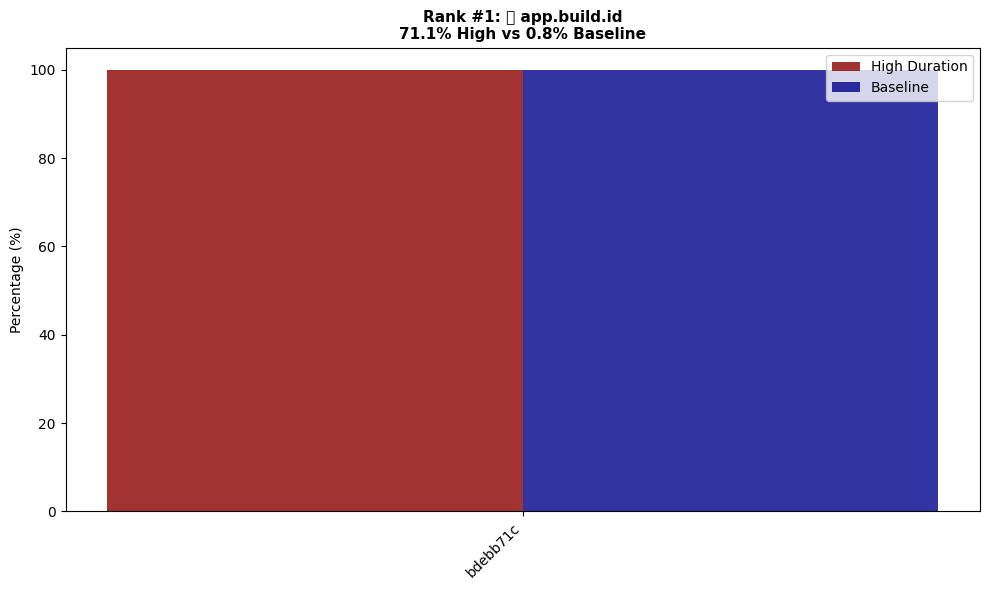

   ✅ Chart created successfully

📋 2. app.request.id (Parsed Attribute):
   🔴 High Duration: 3,885 spans (71.1%)
   🔵 Baseline: 850 spans (0.8%)
   📊 Difference: +70.3 percentage points
   🎯 Score: 0.709
   📊 app.request.id has 4270 unique values - using top 50 most frequent


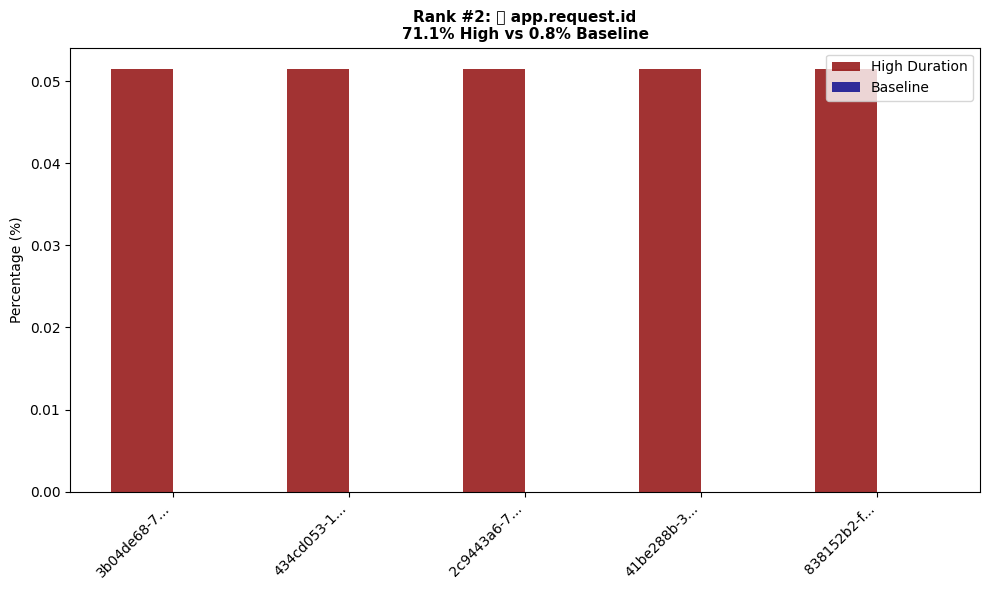

   ✅ Chart created successfully

📋 3. app.user.id (Parsed Attribute):
   🔴 High Duration: 3,885 spans (71.1%)
   🔵 Baseline: 1,315 spans (1.3%)
   📊 Difference: +69.9 percentage points
   🎯 Score: 0.708
   📊 app.user.id has 2135 unique values - using top 50 most frequent


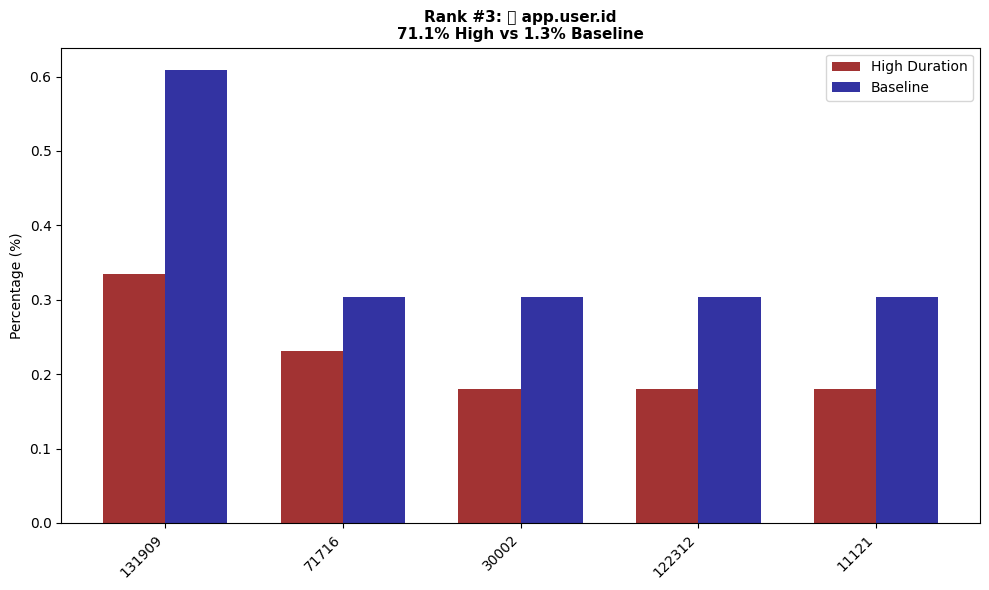

   ✅ Chart created successfully

📋 4. Attributes (Standard Column):
   🔴 High Duration: 5,461 spans (100.0%)
   🔵 Baseline: 103,744 spans (100.0%)
   📊 Difference: +0.0 percentage points
   🎯 Score: 0.700
   📊 Attributes has 5935 unique values - using top 50 most frequent


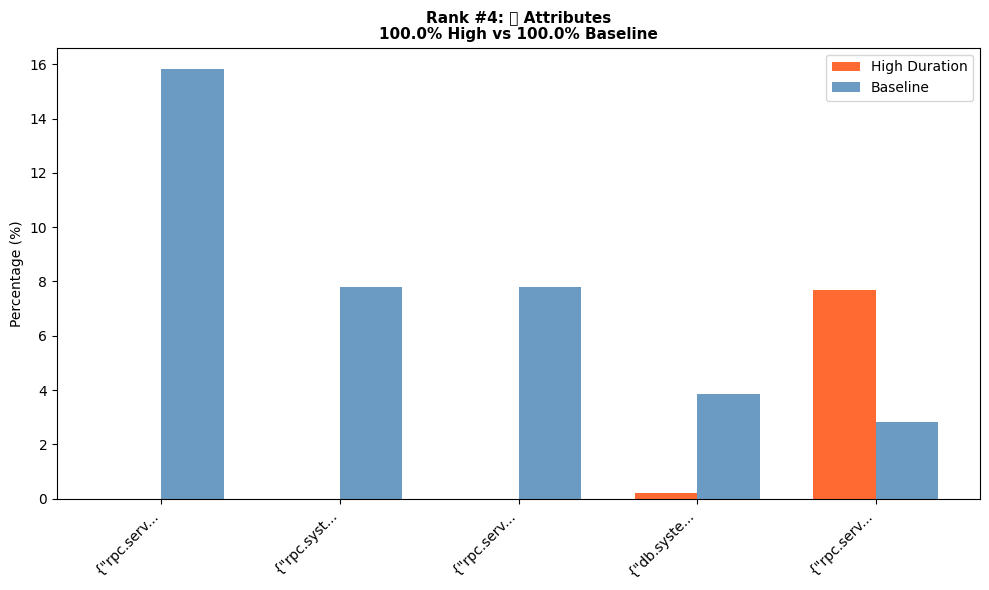

   ✅ Chart created successfully

📋 5. ServiceName (Standard Column):
   🔴 High Duration: 5,461 spans (100.0%)
   🔵 Baseline: 103,744 spans (100.0%)
   📊 Difference: +0.0 percentage points
   🎯 Score: 0.700


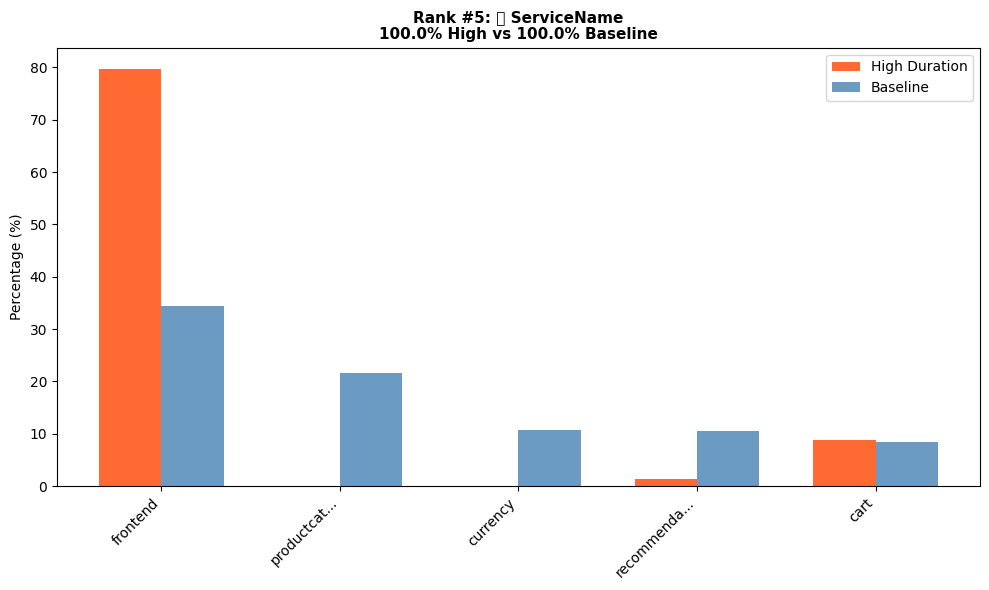

   ✅ Chart created successfully

📋 6. duration_bin (Standard Column):
   🔴 High Duration: 5,461 spans (100.0%)
   🔵 Baseline: 103,744 spans (100.0%)
   📊 Difference: +0.0 percentage points
   🎯 Score: 0.700


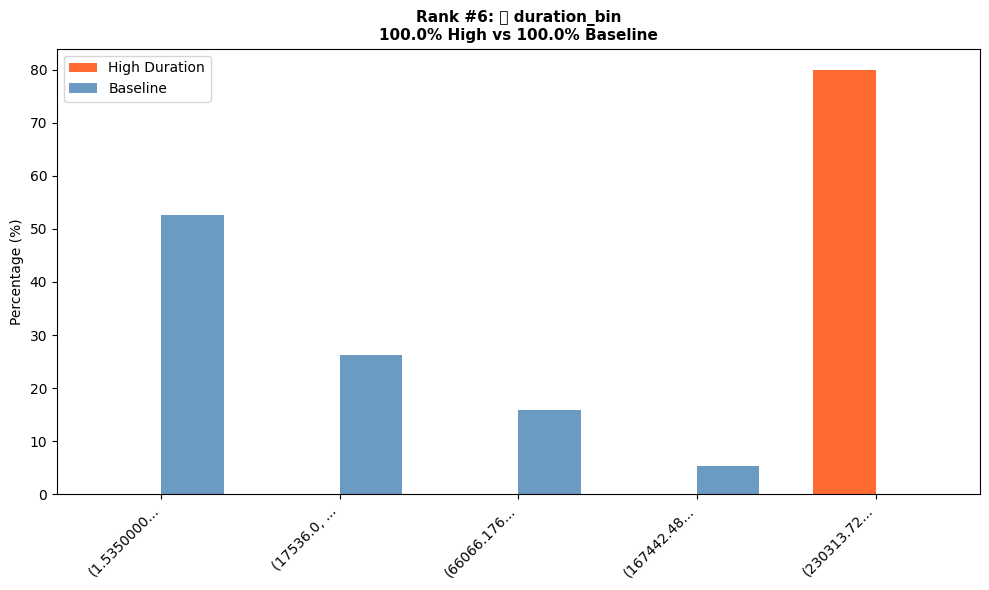

   ✅ Chart created successfully

📋 7. ParentSpanId (Standard Column):
   🔴 High Duration: 5,461 spans (100.0%)
   🔵 Baseline: 103,744 spans (100.0%)
   📊 Difference: +0.0 percentage points
   🎯 Score: 0.700
   📊 ParentSpanId has 63872 unique values - using top 50 most frequent


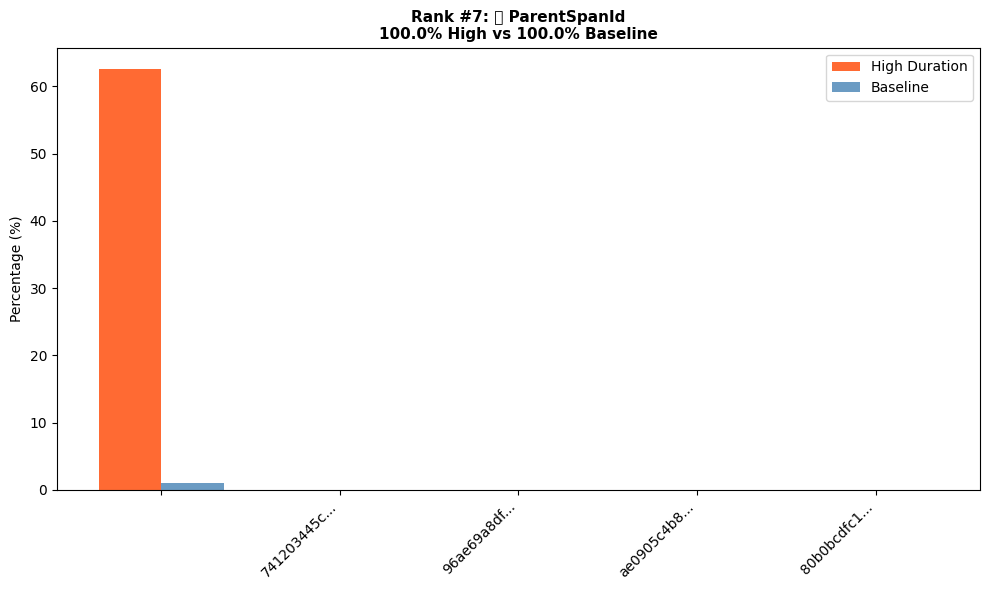

   ✅ Chart created successfully

📋 8. Name (Standard Column):
   🔴 High Duration: 5,461 spans (100.0%)
   🔵 Baseline: 103,744 spans (100.0%)
   📊 Difference: +0.0 percentage points
   🎯 Score: 0.700


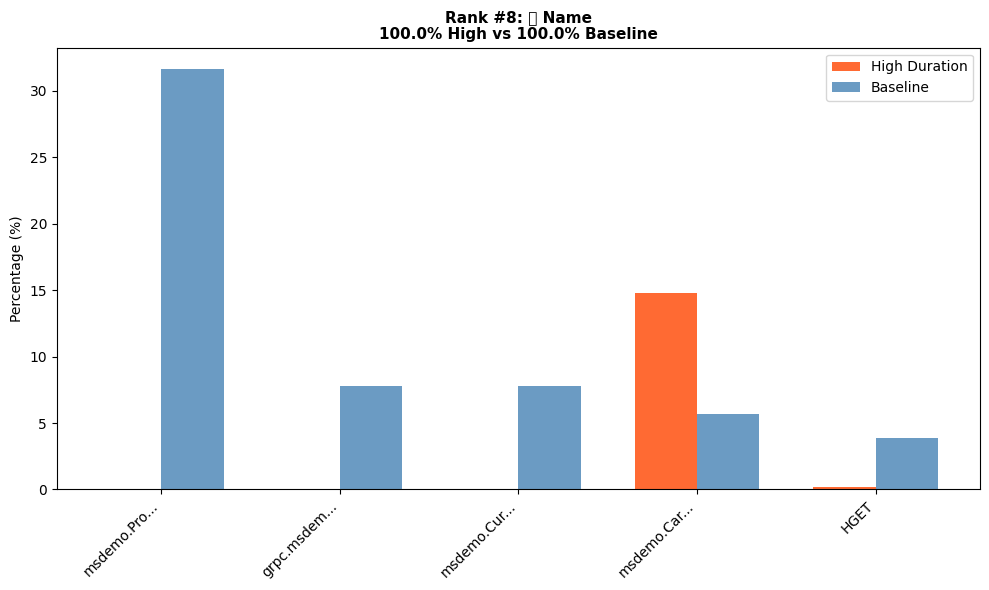

   ✅ Chart created successfully

📋 9. StatusCode (Standard Column):
   🔴 High Duration: 5,461 spans (100.0%)
   🔵 Baseline: 103,744 spans (100.0%)
   📊 Difference: +0.0 percentage points
   🎯 Score: 0.700


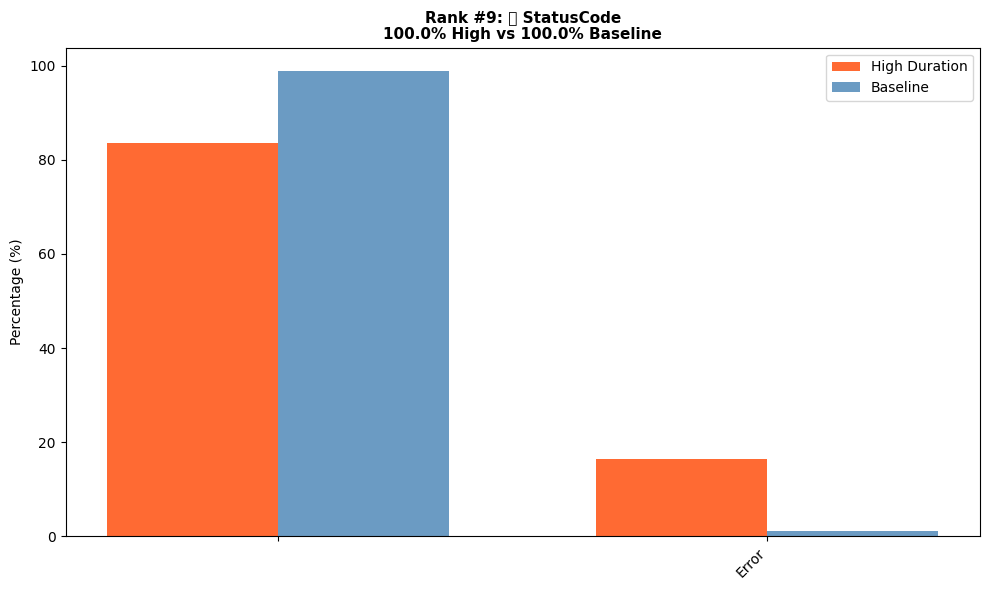

   ✅ Chart created successfully

📋 10. http.target (Parsed Attribute):
   🔴 High Duration: 3,890 spans (71.2%)
   🔵 Baseline: 4,640 spans (4.5%)
   📊 Difference: +66.8 percentage points
   🎯 Score: 0.699


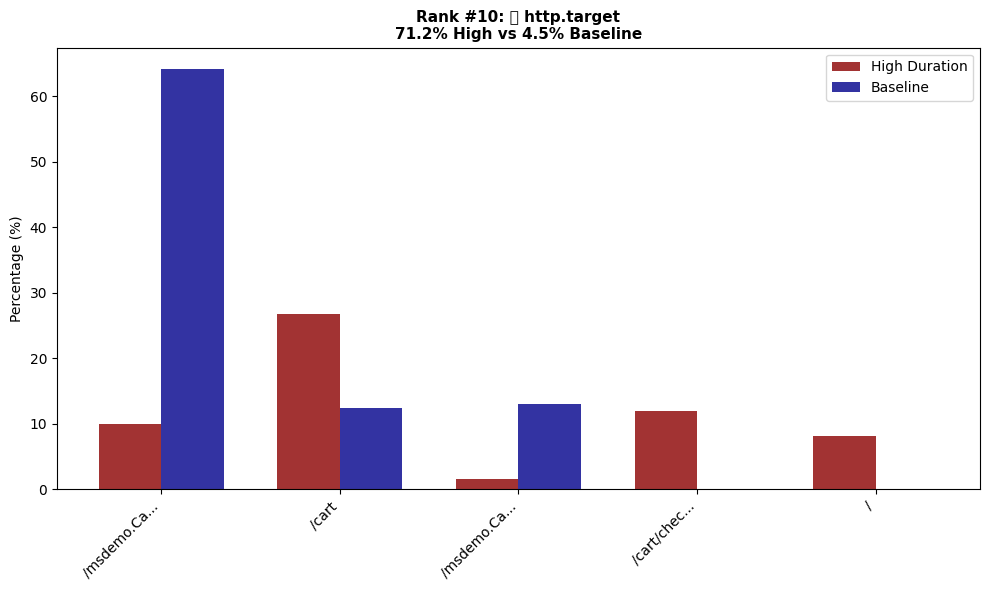

   ✅ Chart created successfully

✅ TOP COLUMNS ANALYSIS COMPLETE
   📊 Total columns available: 60
   📈 Charts created: 10
   ⚠️ Charts skipped: 0
   🎯 Showing top 10 by high duration percentage
   💡 Limited to 10 charts to avoid performance issues

🔍 REMAINING HIGH-VALUE COLUMNS (not charted):
   11. http.status.code: 71.2% high vs 4.5% baseline
   12. http.method: 71.2% high vs 4.5% baseline
   13. net.sock.peer.port: 85.5% high vs 58.4% baseline
   14. net.sock.peer.addr: 85.5% high vs 58.4% baseline
   15. time_bin: 94.6% high vs 94.7% baseline
   16. net.protocol.version: 62.6% high vs 0.8% baseline
   17. http.route: 62.6% high vs 0.8% baseline
   18. net.host.name: 62.6% high vs 0.8% baseline
   19. http.scheme: 62.6% high vs 0.8% baseline
   20. user.agent.original: 62.6% high vs 0.8% baseline


In [33]:
# Generate comparison graphs for TOP columns ranked by high duration percentage (OPTIMIZED)
print("📊 GENERATING GRAPHS FOR TOP COLUMNS RANKED BY HIGH DURATION PERCENTAGE")
print("=" * 70)

# Check if required variables exist
if 'comparison_groups' not in globals():
    print("❌ Cannot proceed without comparison_groups")
elif 'ranked_attributes' not in globals():
    print("❌ Cannot proceed without ranked_attributes. Please run the ranking cell first.")
else:
    import matplotlib.pyplot as plt
    import seaborn as sns
    from collections import Counter
    import numpy as np

    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    print("✅ All required variables are available")
    print(f"📊 Total ranked columns/attributes: {len(ranked_attributes)}")

    def create_simple_column_chart(column_info):
        """
        Create a simplified comparison chart for faster execution
        """
        display_name = column_info[0]
        metadata = column_info[2]
        column_name = metadata['column_name']
        column_type = metadata['column_type']
        
        # Get high duration and baseline groups
        high_group = comparison_groups['high_duration']
        baseline_group = comparison_groups['baseline']
        
        # Get data for both groups
        high_data = high_group[column_name].dropna()
        baseline_data = baseline_group[column_name].dropna()
        
        if len(high_data) == 0 and len(baseline_data) == 0:
            return None
            
        # Limit analysis to top 5 values only for speed
        high_counts = Counter(high_data) if len(high_data) > 0 else Counter()
        baseline_counts = Counter(baseline_data) if len(baseline_data) > 0 else Counter()
        
        all_values = set(list(high_counts.keys()) + list(baseline_counts.keys()))
        
        # If too many unique values, limit to top 50 by frequency
        if len(all_values) > 50:
            print(f"   📊 {display_name} has {len(all_values)} unique values - using top 50 most frequent")
            # Get top 50 values by total frequency across both groups
            top_50_values = sorted(all_values, 
                                 key=lambda x: high_counts.get(x, 0) + baseline_counts.get(x, 0), 
                                 reverse=True)[:50]
            all_values = set(top_50_values)
        
        # Get top 5 values only for visualization (from the filtered set)
        top_values = sorted(all_values, 
                          key=lambda x: high_counts.get(x, 0) + baseline_counts.get(x, 0), 
                          reverse=True)[:5]
        
        if not top_values:
            return None
            
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))  # Smaller figure for speed
        
        # Calculate percentages
        high_percentages = []
        baseline_percentages = []
        
        total_high = len(high_data) if len(high_data) > 0 else 1
        total_baseline = len(baseline_data) if len(baseline_data) > 0 else 1
        
        for val in top_values:
            high_percentages.append((high_counts.get(val, 0) / total_high) * 100)
            baseline_percentages.append((baseline_counts.get(val, 0) / total_baseline) * 100)
        
        # Create simple bars
        x_pos = np.arange(len(top_values))
        width = 0.35
        
        # Color coding based on column type
        if column_type == "Parsed Attribute":
            high_color = 'darkred'
            baseline_color = 'darkblue'
        else:
            high_color = 'orangered'
            baseline_color = 'steelblue'
        
        ax.bar(x_pos - width/2, high_percentages, width, 
               label='High Duration', color=high_color, alpha=0.8)
        ax.bar(x_pos + width/2, baseline_percentages, width, 
               label='Baseline', color=baseline_color, alpha=0.8)
        
        # Simple title
        type_indicator = "🏷️" if column_type == "Parsed Attribute" else "📋"
        title = f'{type_indicator} {display_name}\n'
        title += f'{metadata["high_percentage"]:.1f}% High vs {metadata["baseline_percentage"]:.1f}% Baseline'
        
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel('Percentage (%)')
        ax.set_xticks(x_pos)
        
        # Format labels
        labels = [str(val)[:10] + '...' if len(str(val)) > 10 else str(val) for val in top_values]
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.legend()
        
        plt.tight_layout()
        return fig

    # Show summary of what we're analyzing
    attr_count = sum(1 for _, _, meta in ranked_attributes if meta['column_type'] == "Parsed Attribute")
    std_count = len(ranked_attributes) - attr_count
    
    print(f"\n📈 AVAILABLE FOR ANALYSIS:")
    print(f"   📋 Standard Columns: {std_count}")
    print(f"   🏷️  Parsed Attributes: {attr_count}")
    print(f"   📊 Total: {len(ranked_attributes)}")
    
    # LIMIT to top 6 only to avoid infinite loops
    MAX_CHARTS = 10
    print(f"\n💡 Generating charts for TOP {MAX_CHARTS} columns/attributes only...")
    print("=" * 70)

    # Generate graphs for top columns/attributes (LIMITED)
    figures_created = 0
    skipped_count = 0
    
    for i, column_info in enumerate(ranked_attributes[:MAX_CHARTS], 1):
        display_name, score, metadata = column_info
        
        print(f"\n📋 {i}. {display_name} ({metadata['column_type']}):")
        print(f"   🔴 High Duration: {metadata['high_count']:,} spans ({metadata['high_percentage']:.1f}%)")
        print(f"   🔵 Baseline: {metadata['baseline_count']:,} spans ({metadata['baseline_percentage']:.1f}%)")
        print(f"   📊 Difference: {metadata['difference']:+.1f} percentage points")
        print(f"   🎯 Score: {metadata['importance_score']:.3f}")
        
        try:
            fig = create_simple_column_chart(column_info)
            
            if fig is not None:
                # Add ranking info to title
                ax = fig.gca()
                original_title = ax.get_title()
                new_title = f"Rank #{i}: {original_title}"
                ax.set_title(new_title, fontsize=11, fontweight='bold')
                
                plt.show()
                figures_created += 1
                print(f"   ✅ Chart created successfully")
            else:
                print(f"   ⚠️ Skipped - no useful data to display")
                skipped_count += 1
        except Exception as e:
            print(f"   ❌ Error creating chart: {str(e)[:100]}...")
            skipped_count += 1
            continue

    print(f"\n✅ TOP COLUMNS ANALYSIS COMPLETE")
    print(f"   📊 Total columns available: {len(ranked_attributes)}")
    print(f"   📈 Charts created: {figures_created}")
    print(f"   ⚠️ Charts skipped: {skipped_count}")
    print(f"   🎯 Showing top {MAX_CHARTS} by high duration percentage")
    print(f"   💡 Limited to {MAX_CHARTS} charts to avoid performance issues")
    
    if len(ranked_attributes) > MAX_CHARTS:
        print(f"\n🔍 REMAINING HIGH-VALUE COLUMNS (not charted):")
        for i, (name, score, meta) in enumerate(ranked_attributes[MAX_CHARTS:MAX_CHARTS+10], MAX_CHARTS+1):
            print(f"   {i}. {name}: {meta['high_percentage']:.1f}% high vs {meta['baseline_percentage']:.1f}% baseline")